## Notebook Objectives
 - Load a model from the checkpoint file
 - plot the loss functions
 - plot the latent dimensions
 - GMM to latent dimensions
 - Analysis of RMSD, RMTD, Potential, Repulsion on:
   - Test Set
   - Decoded Test Set
   - GMM'ed Set

In [1]:
from typing import Optional, Any
import shutil, os, jax, flax, optax, json, matplotlib, glob
import matplotlib.pyplot as plt
import netCDF4 as nc
import numpy as np
from jax import random, numpy as jnp
#from pyscripts.Maths import Maths
#from pyscripts.NN_models import *
from flax import linen as nn
from flax.training import checkpoints, train_state
from flax import struct, serialization
import orbax.checkpoint
import mdtraj as md
#from pyscripts.AutoEncoder_Experiment import AutoEncoder_Experiment

2024-04-10 22:05:42.881069: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [ ]:
class Experiment_Analyzer():
    def __init__(self, json_info, netcdf_fn, chkpt_fn):
        if type(json_info) is str:
            with open(json_info, 'r') as f:
                self.json_params = json.load(f)
        elif type(json_info) is dict:
            self.json_params = json_info
        else:
            raise Exception('json_info should be a string (to load the file) or dict (if the file is loaded already)')
        #Files
        fname_dcd = self.json_params["files"]["fname_dcd"]
        fname_prmtop = self.json_params["files"]["fname_prmtop"]
        save_dir = self.json_params["files"]["save_dir"]
        self.math = Maths(fname_prmtop)
        self.model_name = self.json_params["model"]["model_name"]
        model_dir = os.path.join(save_dir, f'{self.model_name}/')
        self.n_latents = self.json_params["training"]["arch"]["latent_dim"]
        activators = self.json_params["training"]["arch"]["activators"]
        layer_ops = self.json_params["training"]["arch"]["layer_ops"]
        dropout_rates = self.json_params["training"]["arch"]["dropout_rates"]
        self.batch_size = self.json_params["training"]["arch"]["batch_size"]
        learning_rate = self.json_params["training"]["arch"]["learning_rate"]
        test_slice = self.json_params["training"]["data"]["test_slice"]
        rng_key = self.json_params["training"]["arch"]["rng_key"]
        
        if self.json_params["files"]["data_dir"] == 'None':
            latent_dir = os.path.join(model_dir, f'{self.n_latents:02d}_latents/')
            self.data_dir = os.path.join(latent_dir, f'rpt_{test_slice}/')
        else:
            self.data_dir = self.json_params["files"]["data_dir"]
        
        #Test and Train Data
        data_start = self.json_params["training"]["data"]["data_slice_start"]
        data_end = self.json_params["training"]["data"]["data_slice_end"]
        if data_end == 'None':
            data_end = None
        
        
        
        #Load and Align
        c = md.load(fname_dcd, top=fname_prmtop)
        c = c.superpose(c) # FEED IN ALIGNED DATA
        coord_set = jnp.array(c.xyz.reshape(c.xyz.shape[0], -1))[data_start:data_end] # reshape to be n_conf, 3*n_atom 
        num_samples, input_size = coord_set.shape

        #Make test and train sets - indices, then sets
        test_indices = np.array(range(test_slice, num_samples, 5)) #every fifth frame
        train_indices = np.array([element for element in range(num_samples) if element not in test_indices])
        self.test_data = coord_set[test_indices]
        self.train_data = coord_set[train_indices]
        print(self.train_data.shape, self.test_data.shape)
        
        #Set Test and Train data into batches - Train
        num_train = self.train_data.shape[0]
        num_complete_batches, leftover = divmod(num_train, self.batch_size)
        self.num_train_batches = num_complete_batches + bool(leftover)
        self.train_batches = DataStream(self.n_latents, num_train, self.num_train_batches, self.batch_size, self.train_data)
        
        #Set Test and Train data into batches - Test
        num_test = self.test_data.shape[0]
        num_complete_batches, leftover = divmod(num_test, self.batch_size)
        self.num_test_batches = num_complete_batches + bool(leftover)
        self.test_batches = DataStream(self.n_latents, num_test, self.num_test_batches, self.batch_size, self.test_data)

        self.nc = nc.Dataset(netcdf_fn, 'r')
        
        if self.json_params["training"]["arch"]["hidden_layers"] != "Auto":
            hidden_layers = self.json_params["training"]["arch"]["hidden_layers"]
        else:
            hidden_layers = [input_size]*3
        
        activators = [eval(activator) for activator in activators]
        layer_ops = [eval(layer_op) for layer_op in layer_ops]
        self.model = AutoEncoder(input_size=input_size, n_latents=self.n_latents,
                                 hidden_layers=hidden_layers, activators=activators,
                                 layer_ops=layer_ops, dropout_rates=dropout_rates)
        rng_init = jax.random.PRNGKey(rng_key)
        rng, key = jax.random.split(rng_init)
        self.state = train_state.TrainState.create(apply_fn=self.model.apply,
                                                   params=self.model.init(key, coord_set, rng)['params'],
                                                   tx=optax.adam(learning_rate=learning_rate))
        orbax_checkpointer = orbax.checkpoint.PyTreeCheckpointer()
        self.state = orbax_checkpointer.restore(chkpt_fn, item=self.state)

    def plot_losses(self):
        traingrp = self.nc.groups['Train']
        testgrp = self.nc.groups['Test']
        for foo in ['RMSD', 'RMTD', 'Potential', 'Repulsion']:
            plt.clf()
            plt.title(foo)
            if foo != 'Repulsion':
                for grp in [traingrp, testgrp]:
                    _ = plt.plot(np.arange(grp.variables[foo][:, :, :].shape[0]),
                                 np.mean(grp.variables[foo][:, :, :], axis=(1, 2)))
            elif foo == 'Repulsion':
                for grp in [traingrp, testgrp]:
                    _ = plt.plot(np.arange(grp.variables[foo][:, :].shape[0]),
                                 np.mean(grp.variables[foo][:, :], axis=(1)))
            plt.xlabel('Epoch')
            plt.yscale('log')
            if foo == 'RMSD':
                plt.ylabel('RMSD (nm)')
            elif foo == 'RMTD':
                plt.ylabel('RMTD (rad)')
            elif foo == 'Potential':
                plt.ylabel('Potential (kJ/mol)')
            plt.show()

### Load the Analyzer

In [ ]:
json_fn = 'Bridges2_Runs/02_24_24/Test_3MP/Test_3MP_16_2.json'
netcdf_fn = 'Bridges2_Runs/02_24_24/Test_3MP/16_latents/rpt_2/model_Test_3MP_16.nc'
ckpt_fn = 'Bridges2_Runs/02_24_24/Test_3MP/16_latents/rpt_2/checkpoint_managed/3999/default/'
#the json is from bridges, change file paths to be from jetstream
#/ocean/projects/mcb160011p/josephdb/githubs/Deep-MMS/ -> /media/volume/sdb/githubs/Deep-MMS/
with open(json_fn, 'r') as f:
    json_params = json.load(f)

for filetype in ["fname_dcd", "fname_prmtop", "save_dir"]:
    json_params['files'][filetype] = json_params['files'][filetype].replace("/ocean/projects/mcb160011p/josephdb/",
                                                                            "/media/volume/sdb/")
self = Experiment_Analyzer(json_params, netcdf_fn, ckpt_fn)

In [ ]:
print(self.nc)
print(self.state.apply_fn)
print(self.math.ener_fun)

In [ ]:
self.nc.groups['Train']

In [6]:
nc_files1 = [sorted(glob.glob(f'bridges2_runs/rpt_{i}/*checkpoint.nc')) for i in [0, 1, 3]]
nc_files = []
for file_group in nc_files1:
    for file in file_group:
        print(file)
        nc_files.append(file)

bridges2_runs/rpt_0/model_AE_Dropout_RMSD_only_0002_checkpoint.nc
bridges2_runs/rpt_0/model_AE_Dropout_RMSD_only_0004_checkpoint.nc
bridges2_runs/rpt_0/model_AE_Dropout_RMSD_only_0008_checkpoint.nc
bridges2_runs/rpt_0/model_AE_Dropout_RMSD_only_0016_checkpoint.nc
bridges2_runs/rpt_0/model_AE_Dropout_RMSD_only_0032_checkpoint.nc
bridges2_runs/rpt_0/model_AE_Dropout_RMSD_only_0064_checkpoint.nc
bridges2_runs/rpt_0/model_AE_Dropout_RMSD_only_0128_checkpoint.nc
bridges2_runs/rpt_0/model_AE_Dropout_RMSD_only_0256_checkpoint.nc
bridges2_runs/rpt_1/model_AE_Dropout_RMSD_only_0002_checkpoint.nc
bridges2_runs/rpt_1/model_AE_Dropout_RMSD_only_0004_checkpoint.nc
bridges2_runs/rpt_1/model_AE_Dropout_RMSD_only_0008_checkpoint.nc
bridges2_runs/rpt_1/model_AE_Dropout_RMSD_only_0016_checkpoint.nc
bridges2_runs/rpt_1/model_AE_Dropout_RMSD_only_0032_checkpoint.nc
bridges2_runs/rpt_1/model_AE_Dropout_RMSD_only_0064_checkpoint.nc
bridges2_runs/rpt_1/model_AE_Dropout_RMSD_only_0128_checkpoint.nc
bridges2_r

In [7]:
def plot_results(filename, print_only=False):
    print(filename)
    dataset = nc.Dataset(filename, 'r')    
    parts = filename.split('_')
    num_latents = parts[-2]
    
    traingrp = dataset.groups['Train']
    testgrp = dataset.groups['Test']
    if not print_only:
        for foo in ['RMSD', 'Potential']:
            plt.clf()
            plt.title(foo + f' {num_latents} Latents')
            for grp in [traingrp, testgrp]:
                _ = plt.plot(np.arange(grp.variables[foo][:, :].shape[0]),
                             np.mean(grp.variables[foo][:, :], axis=1))
            plt.xlabel('Epoch')
            if foo == 'Potential':
                plt.yscale('log')
            
            if foo == 'RMSD':
                plt.ylabel('RMSD (nm)')
            elif foo == 'Potential':
                plt.ylabel('Potential (kJ/mol)')
            plt.legend(['Train','Test'])
            plt.show()
    
    print(f'Num Epochs {traingrp.variables['RMSD'][:, :].shape[0]}')
    print(f'Last RMSD (nm): Train: {np.mean(traingrp.variables['RMSD'][-1, :])} Test {np.mean(testgrp.variables['RMSD'][-1, :])}')
    print(f'Last PotDiff (% Deviation): Train: {np.mean(traingrp.variables['Potential'][-1, :])} Test {np.mean(testgrp.variables['Potential'][-1, :])}')
    dataset.close()

In [11]:
def plot_multiple_ncs(filenames, title=None):
    latents = []
    last_rmsds = []
    last_potentials = []
    
    for file in filenames:
        parts = file.split('_')
        num_latents = parts[-2]
        latents.append(int(num_latents))
        dc = nc.Dataset(file)
        last_rmsds.append([np.mean(dc['Train']['RMSD'][-1,:]), np.mean(dc['Test']['RMSD'][-1,:])])
        last_potentials.append([np.mean(dc['Train']['Potential'][-1,:]), np.mean(dc['Test']['Potential'][-1,:])])
        dc.close()
    latents = np.array(latents)
    last_rmsds = np.array(last_rmsds)
    last_potentials = np.array(last_potentials)
    if title != None:
        plt.clf()
        plt.title(title)
        for i in [0, 1]:
            _ = plt.scatter(latents, last_rmsds[:, i])
        plt.ylabel('RMSD (nm)')
        plt.xlabel('Num Latent Dimensions')
        plt.xscale('log')
        plt.legend(["Train", "Test"])
        plt.show()
        
        plt.clf()
        plt.title(title)
        for i in [0, 1]:
            _ = plt.scatter(latents, np.sqrt(last_potentials[:, i]))
        plt.ylabel('Potential (% dev)')
        plt.yscale('log')
        plt.xlabel('Num Latent Dimensions')
        plt.xscale('log')
        plt.legend(["Train", "Test"])
        plt.show()

        for i in range(len(latents)):
            print(latents[i], last_rmsds[i], last_potentials[i])
    else:
        return latents, last_rmsds, last_potentials

bridges2_runs/rpt_0/model_AE_Dropout_RMSD_only_0002_checkpoint.nc


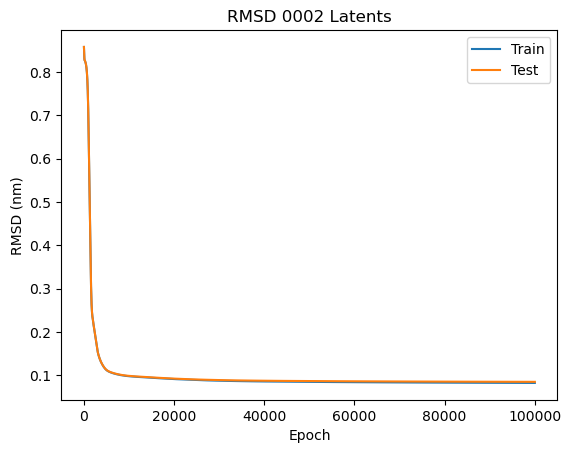

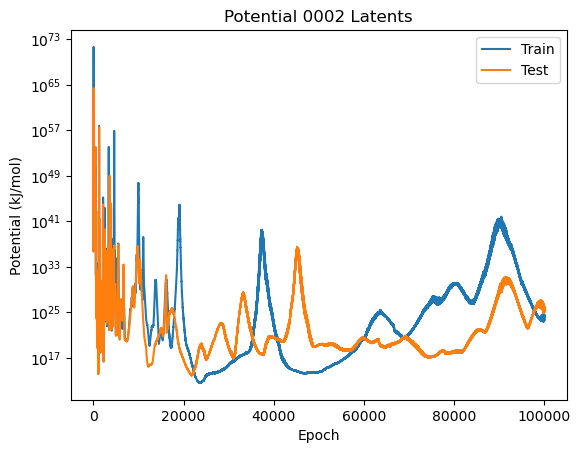

Num Epochs 100000
Last RMSD (nm): Train: 0.0821385383605957 Test 0.08466623723506927
Last PotDiff (% Deviation): Train: 2.3757200694774806e+24 Test 7.220333498357416e+25
bridges2_runs/rpt_0/model_AE_Dropout_RMSD_only_0004_checkpoint.nc


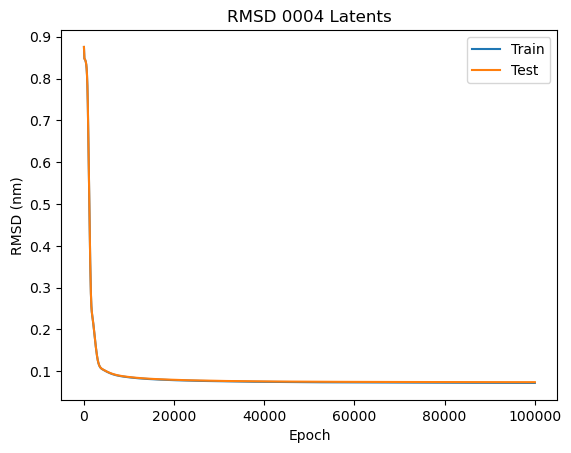

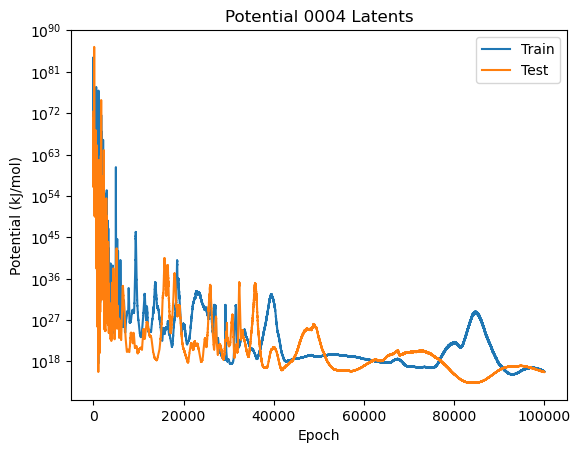

Num Epochs 100000
Last RMSD (nm): Train: 0.07213708013296127 Test 0.0739276185631752
Last PotDiff (% Deviation): Train: 6146235207177950.0 Test 4717613951936121.0
bridges2_runs/rpt_0/model_AE_Dropout_RMSD_only_0008_checkpoint.nc


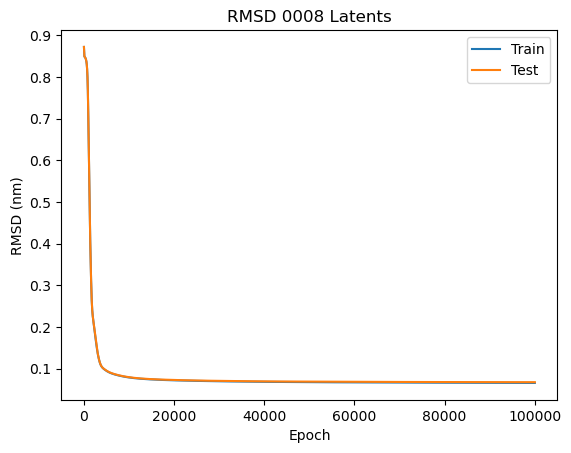

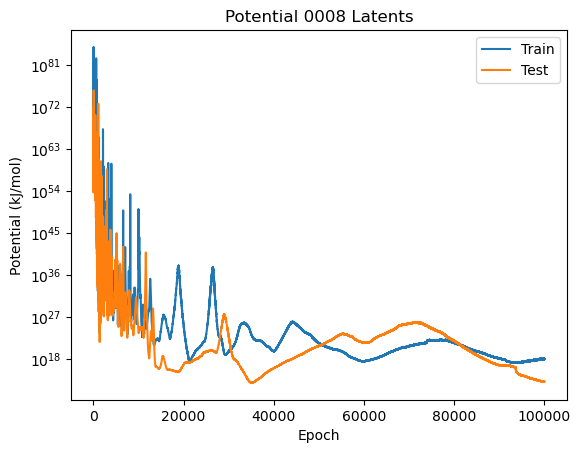

Num Epochs 100000
Last RMSD (nm): Train: 0.06536363065242767 Test 0.06713129580020905
Last PotDiff (% Deviation): Train: 1.204080439407962e+18 Test 14317973701276.432
bridges2_runs/rpt_0/model_AE_Dropout_RMSD_only_0016_checkpoint.nc


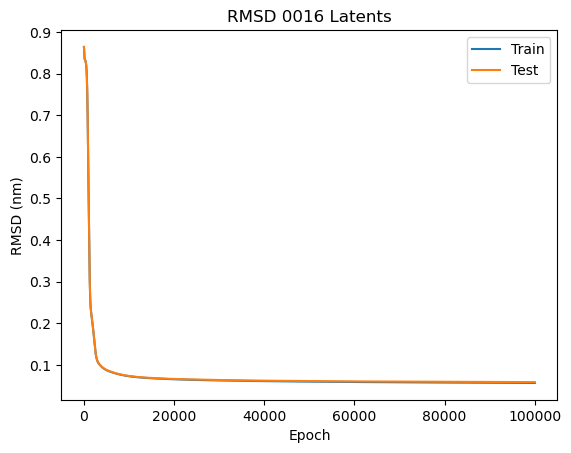

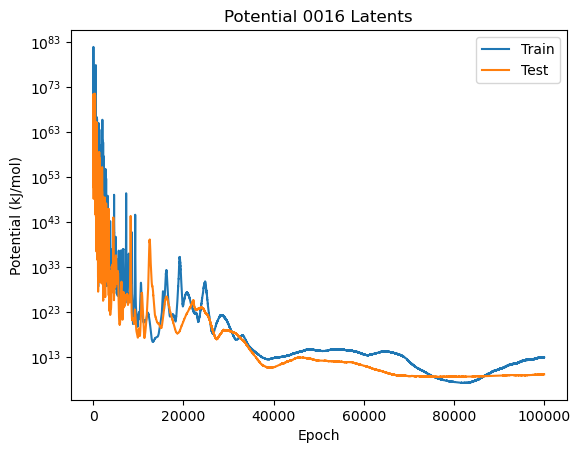

Num Epochs 100000
Last RMSD (nm): Train: 0.056992486119270325 Test 0.05892333760857582
Last PotDiff (% Deviation): Train: 8248479433395.134 Test 1529601994.4016583
bridges2_runs/rpt_0/model_AE_Dropout_RMSD_only_0032_checkpoint.nc


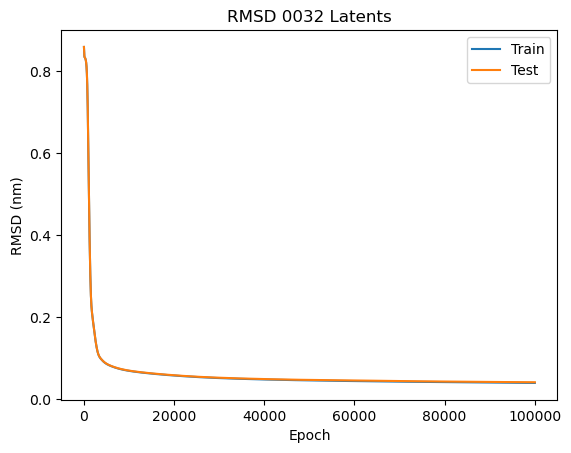

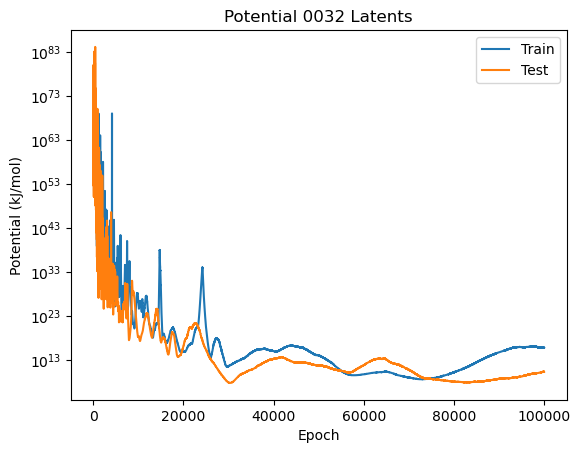

Num Epochs 100000
Last RMSD (nm): Train: 0.039138831198215485 Test 0.040781937539577484
Last PotDiff (% Deviation): Train: 5543590967858660.0 Test 19652486469.586254
bridges2_runs/rpt_0/model_AE_Dropout_RMSD_only_0064_checkpoint.nc


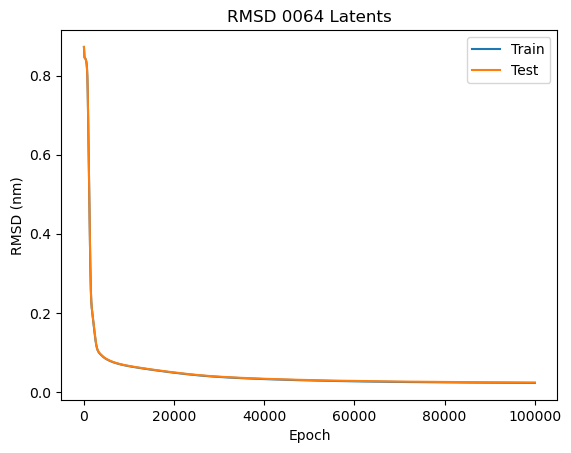

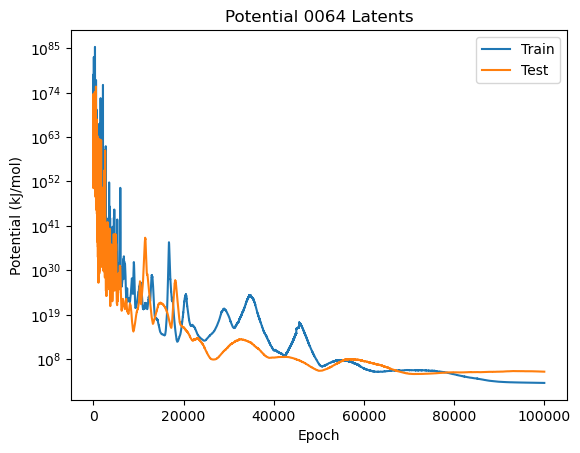

Num Epochs 100000
Last RMSD (nm): Train: 0.022772617638111115 Test 0.023777855560183525
Last PotDiff (% Deviation): Train: 120.5572754912506 Test 73798.09216026885
bridges2_runs/rpt_0/model_AE_Dropout_RMSD_only_0128_checkpoint.nc


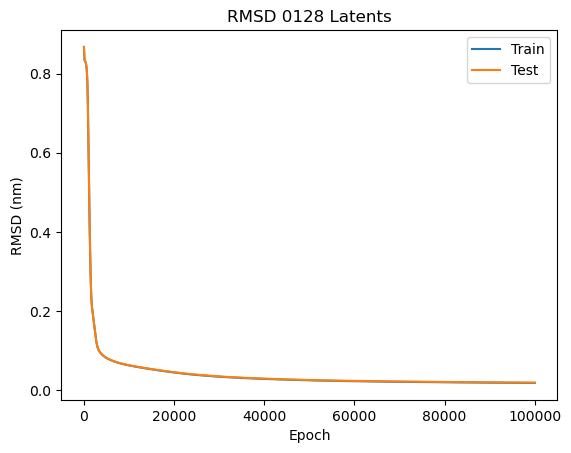

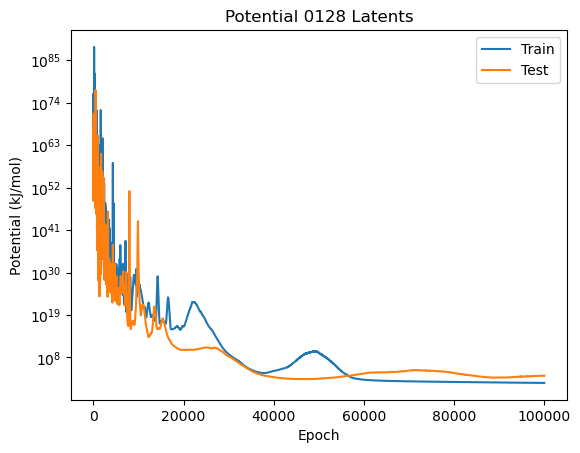

Num Epochs 100000
Last RMSD (nm): Train: 0.01817353442311287 Test 0.018936652690172195
Last PotDiff (% Deviation): Train: 25.762664573213087 Test 2055.126861884808
bridges2_runs/rpt_0/model_AE_Dropout_RMSD_only_0256_checkpoint.nc


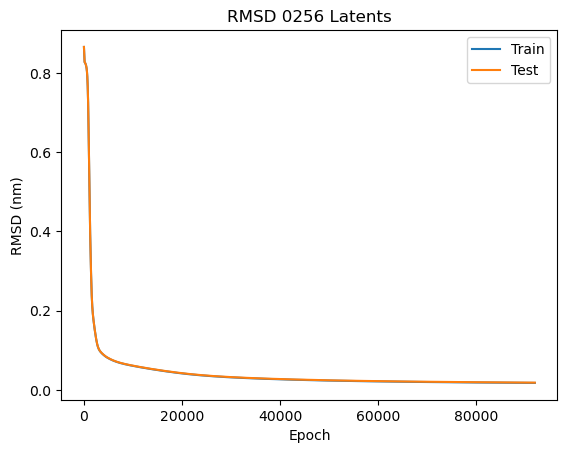

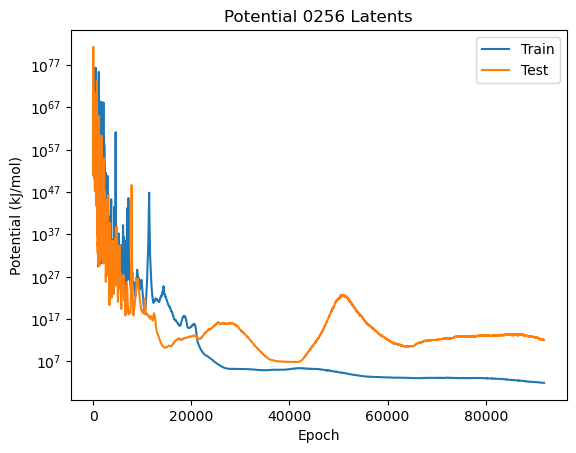

Num Epochs 91900
Last RMSD (nm): Train: 0.01744561642408371 Test 0.018148774281144142
Last PotDiff (% Deviation): Train: 88.47599168285345 Test 1159206132476.727
bridges2_runs/rpt_1/model_AE_Dropout_RMSD_only_0002_checkpoint.nc


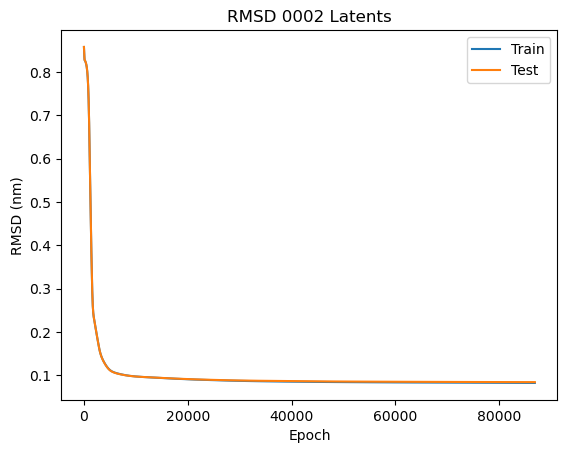

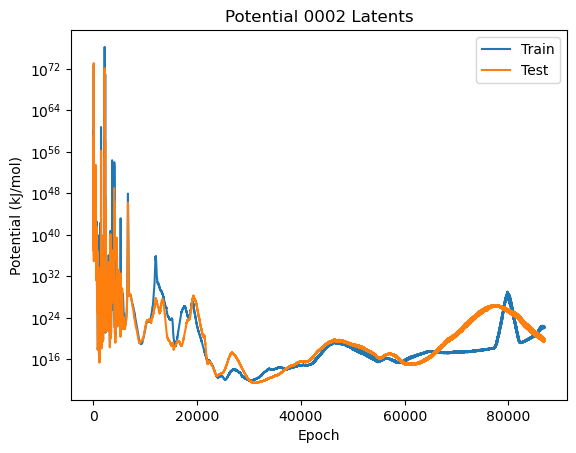

Num Epochs 86900
Last RMSD (nm): Train: 0.08276820182800293 Test 0.08459006249904633
Last PotDiff (% Deviation): Train: 1.2279728675129636e+22 Test 4.668143173905999e+19
bridges2_runs/rpt_1/model_AE_Dropout_RMSD_only_0004_checkpoint.nc


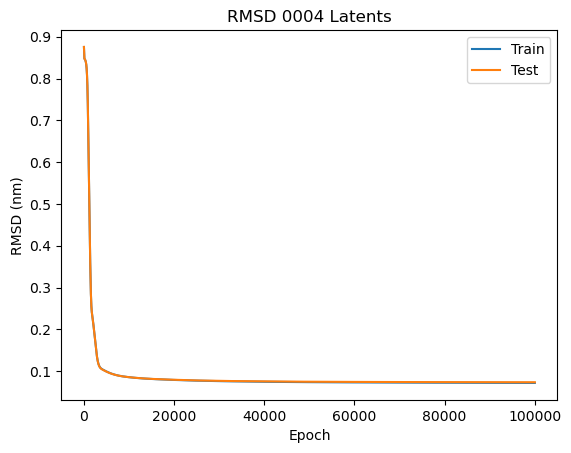

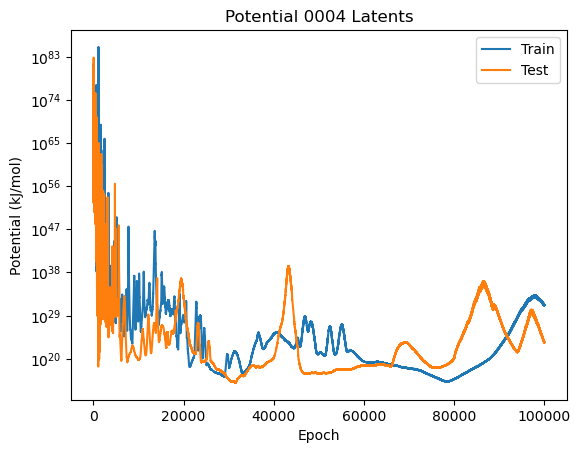

Num Epochs 100000
Last RMSD (nm): Train: 0.07200741022825241 Test 0.07362621277570724
Last PotDiff (% Deviation): Train: 1.3719164974862133e+31 Test 2.4767475755029324e+23
bridges2_runs/rpt_1/model_AE_Dropout_RMSD_only_0008_checkpoint.nc


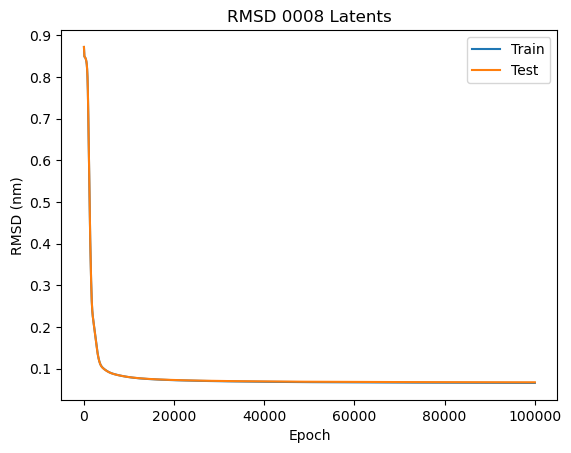

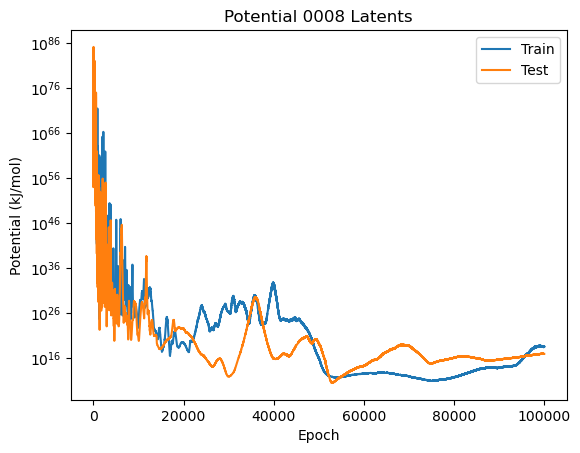

Num Epochs 100000
Last RMSD (nm): Train: 0.06549094617366791 Test 0.0669725239276886
Last PotDiff (% Deviation): Train: 3.260878303758143e+18 Test 8.419242956844403e+16
bridges2_runs/rpt_1/model_AE_Dropout_RMSD_only_0016_checkpoint.nc


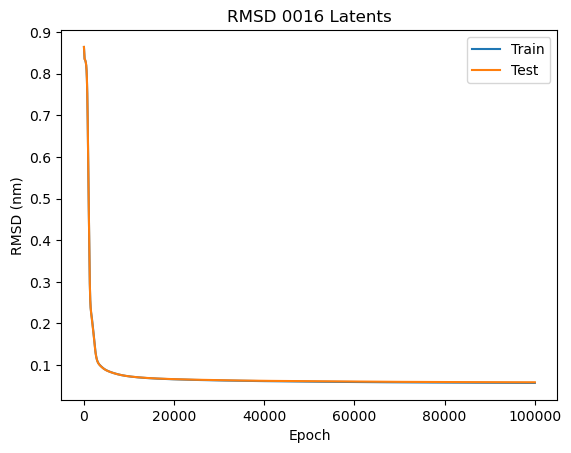

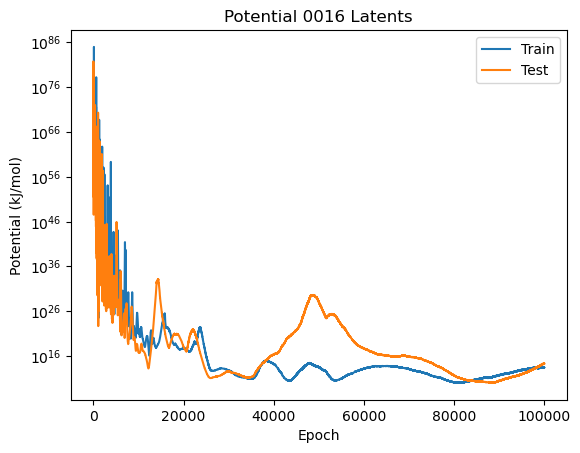

Num Epochs 100000
Last RMSD (nm): Train: 0.05730854347348213 Test 0.05882631987333298
Last PotDiff (% Deviation): Train: 31119605048768.766 Test 254265335927433.0
bridges2_runs/rpt_1/model_AE_Dropout_RMSD_only_0032_checkpoint.nc


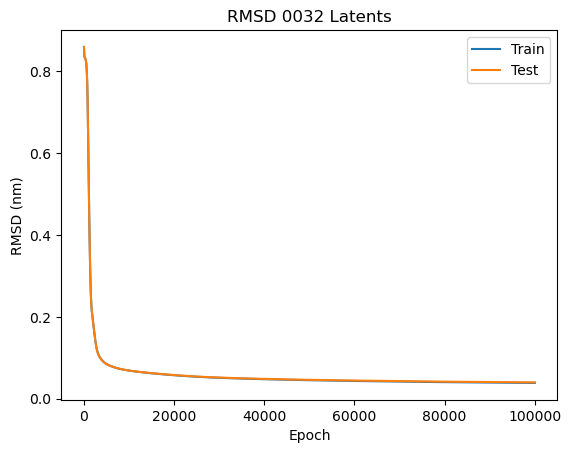

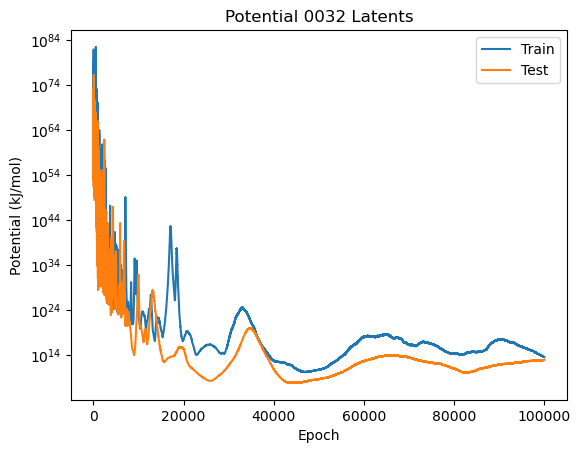

Num Epochs 100000
Last RMSD (nm): Train: 0.03850346431136131 Test 0.03985075280070305
Last PotDiff (% Deviation): Train: 29502487130696.28 Test 6985127936762.856
bridges2_runs/rpt_1/model_AE_Dropout_RMSD_only_0064_checkpoint.nc


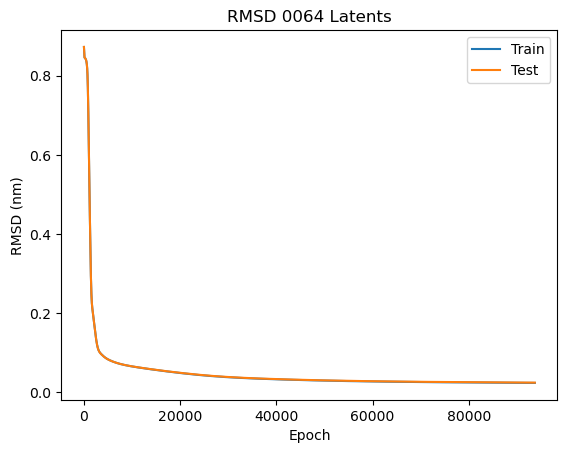

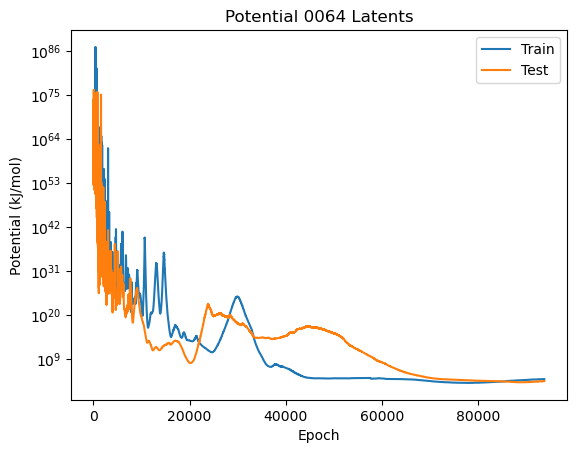

Num Epochs 93700
Last RMSD (nm): Train: 0.02343766950070858 Test 0.024174150079488754
Last PotDiff (% Deviation): Train: 10691.755737588766 Test 3399.2795129944097
bridges2_runs/rpt_1/model_AE_Dropout_RMSD_only_0128_checkpoint.nc


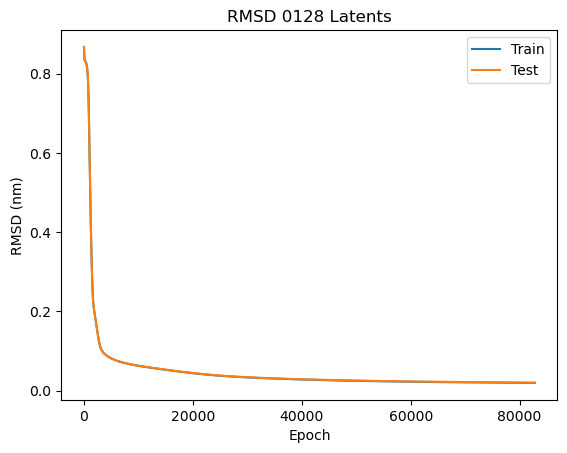

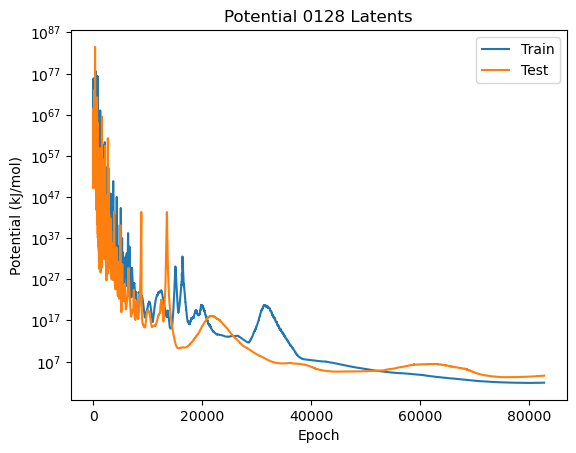

Num Epochs 82800
Last RMSD (nm): Train: 0.019484655931591988 Test 0.020215336233377457
Last PotDiff (% Deviation): Train: 75.3190670293651 Test 3899.2966652419886
bridges2_runs/rpt_1/model_AE_Dropout_RMSD_only_0256_checkpoint.nc


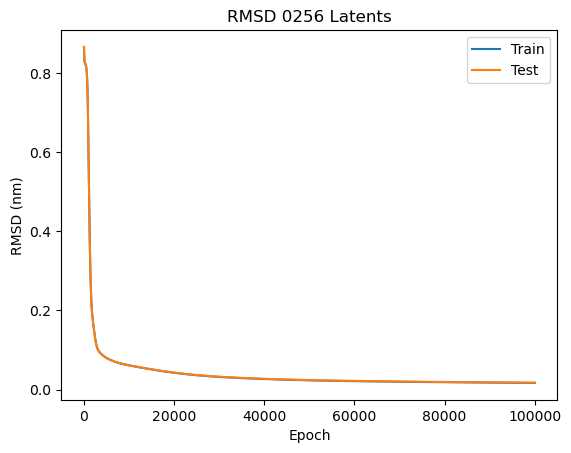

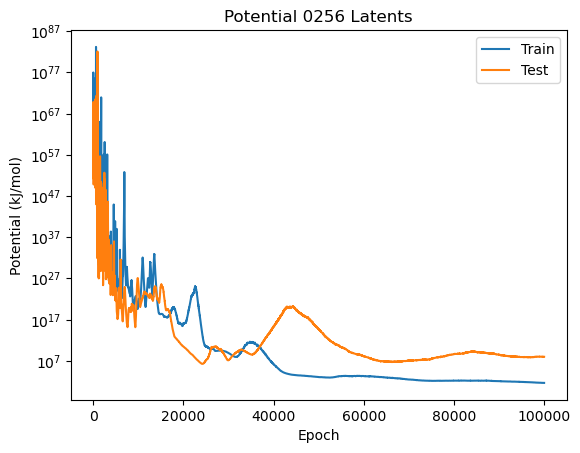

Num Epochs 100000
Last RMSD (nm): Train: 0.017123352736234665 Test 0.017841896042227745
Last PotDiff (% Deviation): Train: 40.368841654111854 Test 88369978.4230235
bridges2_runs/rpt_3/model_AE_Dropout_RMSD_only_0002_checkpoint.nc


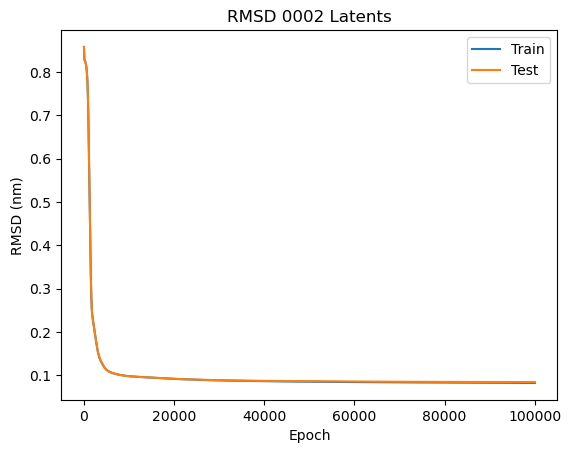

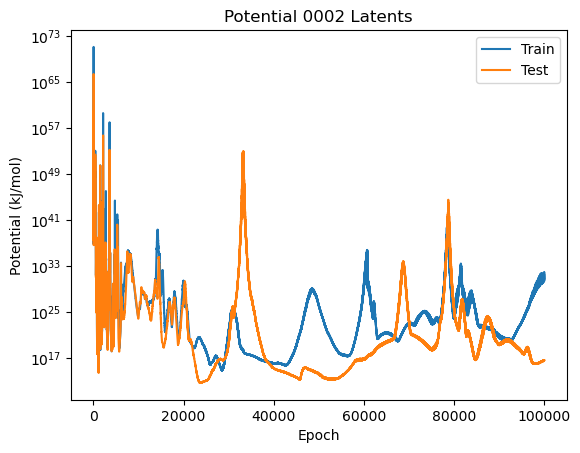

Num Epochs 100000
Last RMSD (nm): Train: 0.08229021728038788 Test 0.08422698825597763
Last PotDiff (% Deviation): Train: 3.234145848958393e+30 Test 3.758918980089221e+16
bridges2_runs/rpt_3/model_AE_Dropout_RMSD_only_0004_checkpoint.nc


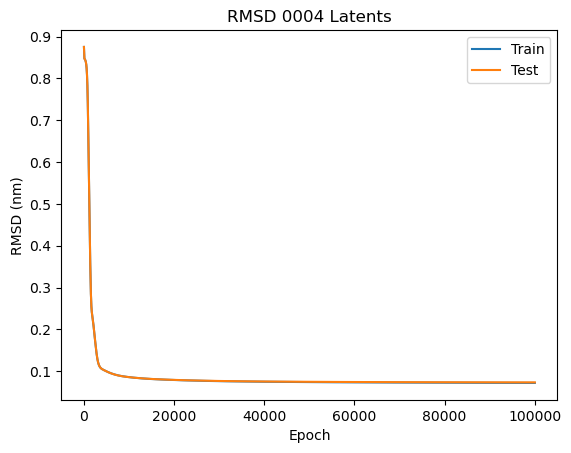

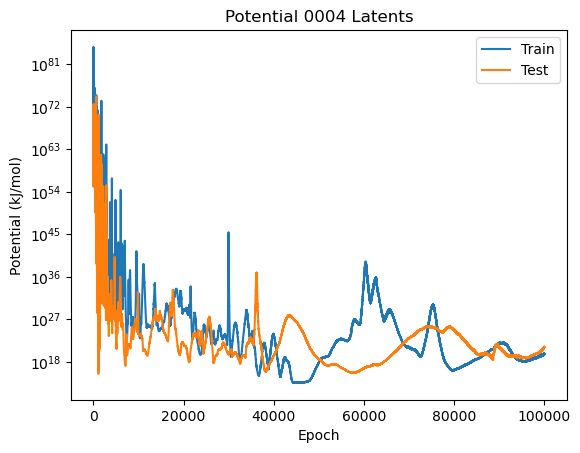

Num Epochs 100000
Last RMSD (nm): Train: 0.07210603356361389 Test 0.07341372966766357
Last PotDiff (% Deviation): Train: 3.4202403749210042e+19 Test 1.147071497546708e+21
bridges2_runs/rpt_3/model_AE_Dropout_RMSD_only_0008_checkpoint.nc


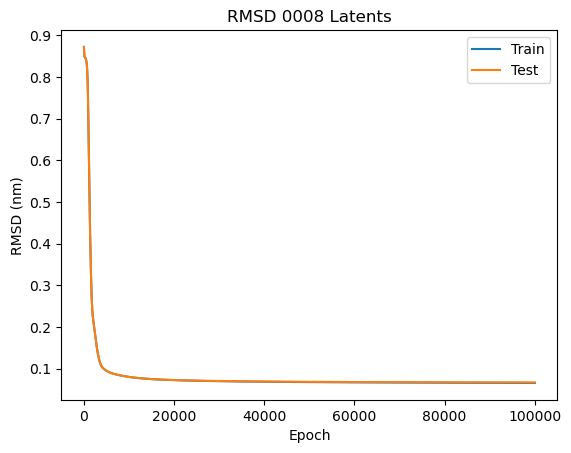

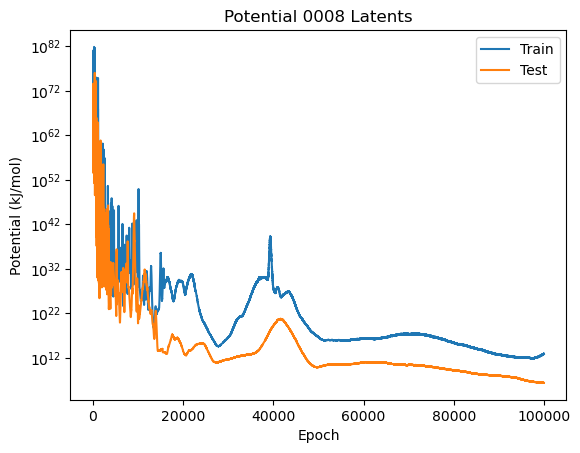

Num Epochs 100000
Last RMSD (nm): Train: 0.06557431817054749 Test 0.06679923832416534
Last PotDiff (% Deviation): Train: 8350879873530.501 Test 2443469.050531404
bridges2_runs/rpt_3/model_AE_Dropout_RMSD_only_0016_checkpoint.nc


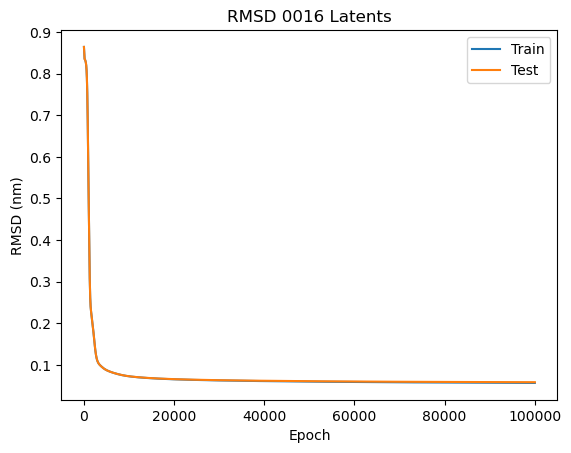

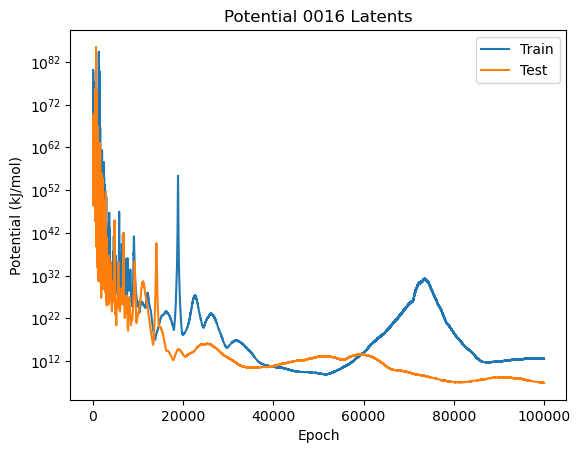

Num Epochs 100000
Last RMSD (nm): Train: 0.05709085613489151 Test 0.05880549177527428
Last PotDiff (% Deviation): Train: 3474737927950.6953 Test 8219630.061037384
bridges2_runs/rpt_3/model_AE_Dropout_RMSD_only_0032_checkpoint.nc


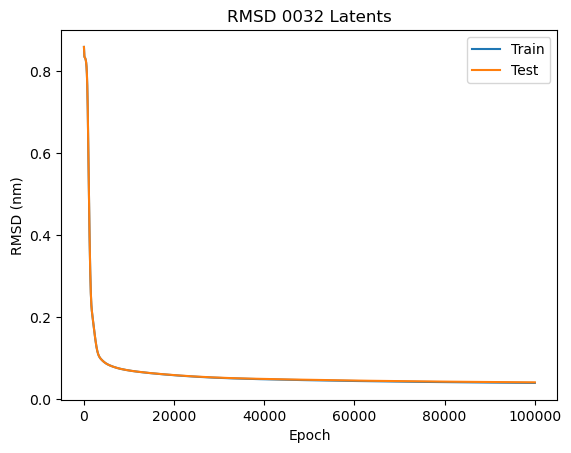

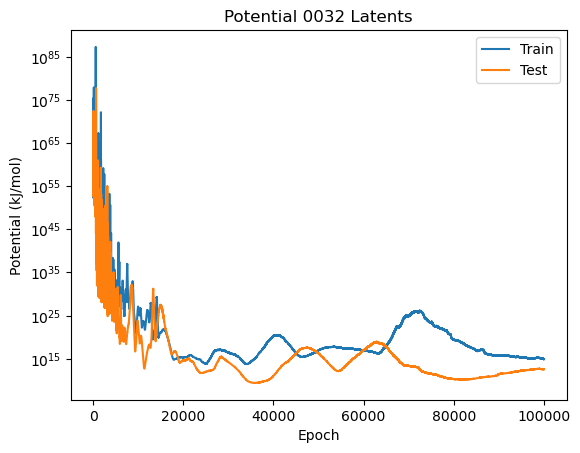

Num Epochs 100000
Last RMSD (nm): Train: 0.03911765664815903 Test 0.04052756354212761
Last PotDiff (% Deviation): Train: 759385139584250.1 Test 3649064828130.889
bridges2_runs/rpt_3/model_AE_Dropout_RMSD_only_0064_checkpoint.nc


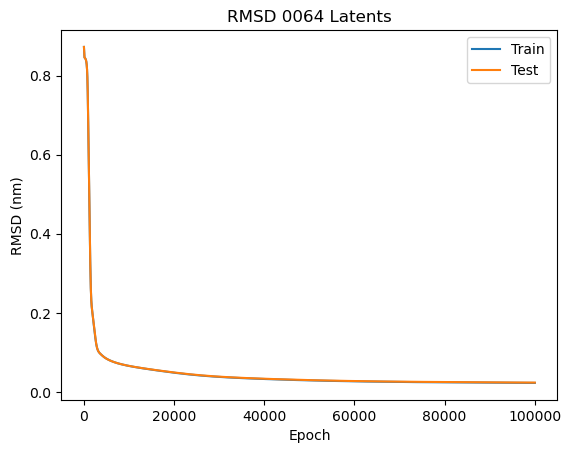

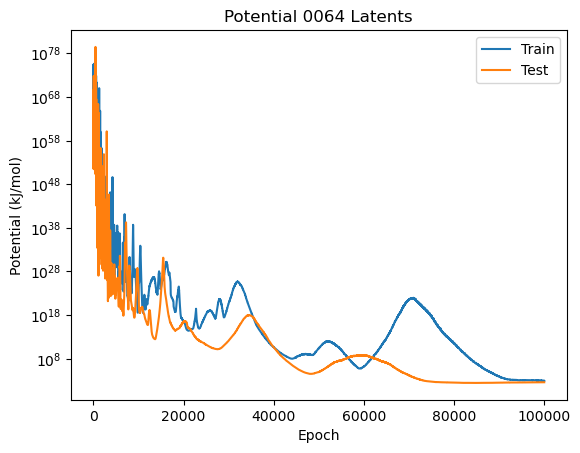

Num Epochs 100000
Last RMSD (nm): Train: 0.022798875346779823 Test 0.023625211790204048
Last PotDiff (% Deviation): Train: 819.0241427441448 Test 404.1027661570573
bridges2_runs/rpt_3/model_AE_Dropout_RMSD_only_0128_checkpoint.nc


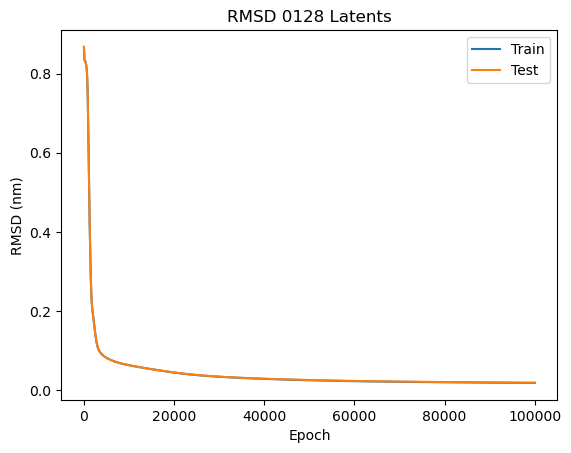

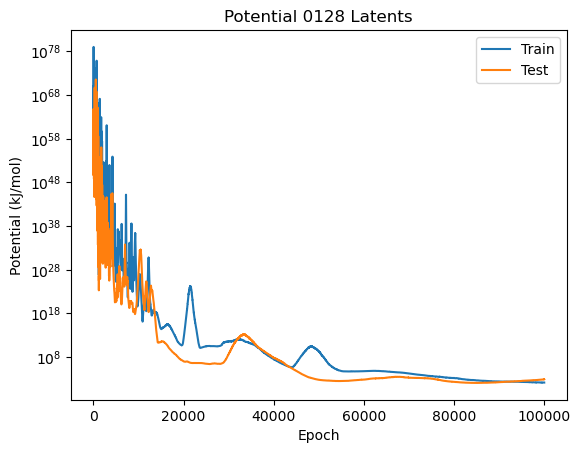

Num Epochs 100000
Last RMSD (nm): Train: 0.01825612783432007 Test 0.018814902752637863
Last PotDiff (% Deviation): Train: 133.32907256499539 Test 702.5780274551223
bridges2_runs/rpt_3/model_AE_Dropout_RMSD_only_0256_checkpoint.nc


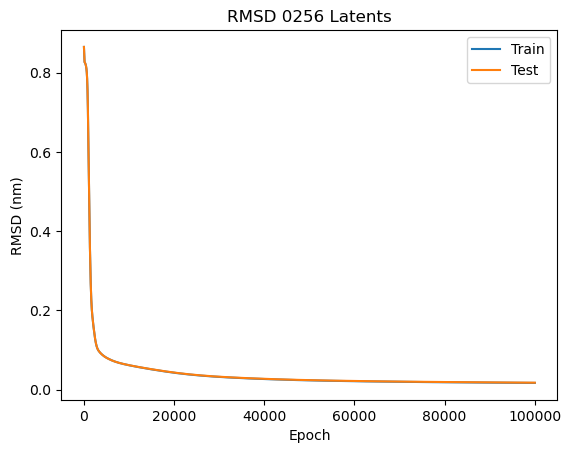

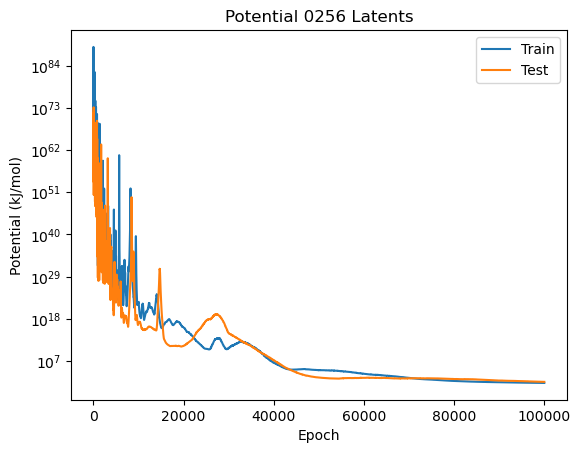

Num Epochs 100000
Last RMSD (nm): Train: 0.016894282773137093 Test 0.01748792640864849
Last PotDiff (% Deviation): Train: 20.407068182126544 Test 38.965595873886066


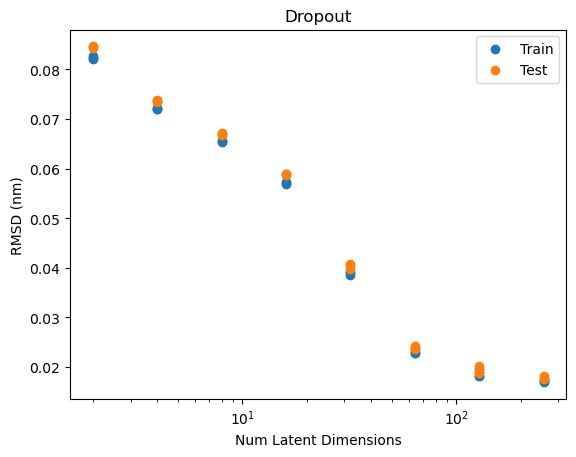

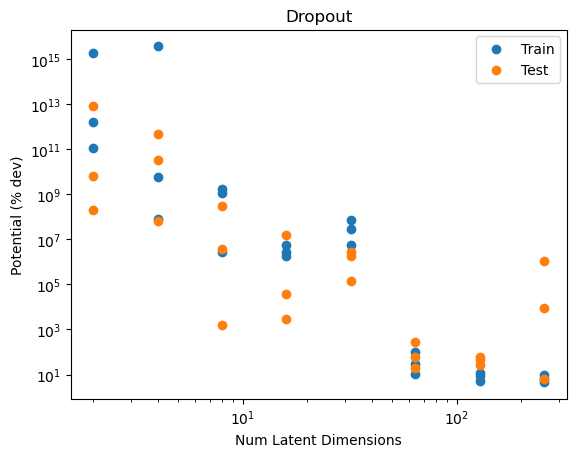

2 [0.08213854 0.08466624] [2.37572007e+24 7.22033350e+25]
4 [0.07213708 0.07392762] [6.14623521e+15 4.71761395e+15]
8 [0.06536363 0.0671313 ] [1.20408044e+18 1.43179737e+13]
16 [0.05699249 0.05892334] [8.24847943e+12 1.52960199e+09]
32 [0.03913883 0.04078194] [5.54359097e+15 1.96524865e+10]
64 [0.02277262 0.02377786] [  120.55727549 73798.09216027]
128 [0.01817353 0.01893665] [  25.76266457 2055.12686188]
256 [0.01744562 0.01814877] [8.84759917e+01 1.15920613e+12]
2 [0.0827682  0.08459006] [1.22797287e+22 4.66814317e+19]
4 [0.07200741 0.07362621] [1.37191650e+31 2.47674758e+23]
8 [0.06549095 0.06697252] [3.26087830e+18 8.41924296e+16]
16 [0.05730854 0.05882632] [3.11196050e+13 2.54265336e+14]
32 [0.03850346 0.03985075] [2.95024871e+13 6.98512794e+12]
64 [0.02343767 0.02417415] [10691.75573759  3399.27951299]
128 [0.01948466 0.02021534] [  75.31906703 3899.29666524]
256 [0.01712335 0.0178419 ] [4.03688417e+01 8.83699784e+07]
2 [0.08229022 0.08422699] [3.23414585e+30 3.75891898e+16]
4 [0

In [12]:
for file in nc_files:
    plot_results(file)
plot_multiple_ncs(nc_files, title='Dropout')

In [ ]:
nc_files = [element for element in sorted(glob.glob('bridges2_runs/model_AE_NO_Drop*.nc')) if "checkpoint" in element]
for file in nc_files:
    print(file)

In [ ]:
for file in nc_files:
    try:
        plot_results(file, print_only=True)
    except:
        print(file, 'ERROR')

In [ ]:
plot_multiple_ncs(nc_files, 'No Dropout')

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [4]:
u = md.load('Simulation/1crn_H_1us_FULL.dcd', top='Simulation/1crn_H.prmtop')
u = u.superpose(u)
coords = u.xyz
print(coords.shape)
coords = coords.reshape(coords.shape[0], -1)
inds = np.arange(0, 100000, 10)
coords = coords[inds]
print(coords.shape)

(100000, 642, 3)
(10000, 1926)


In [5]:
rmsds = md.rmsd(u, u, -1)

In [6]:
rmsds.shape

(100000,)

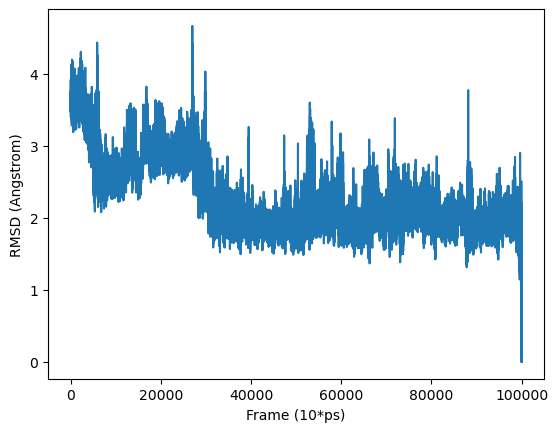

In [7]:
plt.clf()
_ = plt.plot(np.arange(rmsds.shape[0]), 10*rmsds)
plt.xlabel('Frame (10*ps)')
plt.ylabel('RMSD (Angstrom)')
plt.show()

In [32]:
sil_scores = []
clusters = []
for i in range(2, 50):
    print(i)
    clusters.append(i)
    test_kmeans = KMeans(n_clusters=i).fit_predict(coords)
    sil_scores.append(silhouette_score(coords, test_kmeans))

sil_scores = np.array(sil_scores)
clusters = np.array(clusters)

2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26


KeyboardInterrupt: 

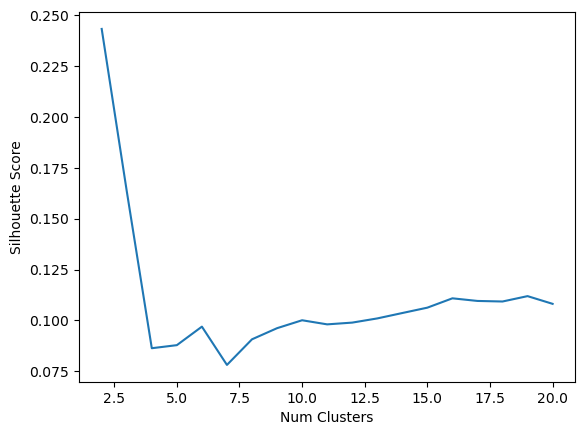

[0.24326938 0.16355656 0.08632892 0.08783334 0.09693222 0.07811742
 0.09070939 0.09617332 0.10007206 0.09805369 0.09891465 0.10097171
 0.10362536 0.1062653  0.11085247 0.1095655  0.10928845 0.11193081
 0.10813986]


In [13]:
plt.clf()
_ = plt.plot(clusters, sil_scores)
plt.xlabel('Num Clusters')
plt.ylabel('Silhouette Score')
plt.show()
print(sil_scores)

In [15]:

def entropy_calculation(coords, num_clusters, num_divisions):
    # For i in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] get the populations of clusters
    entropy_series = []
    ent = lambda p: p*np.log(p)
    kmeans = KMeans(n_clusters=num_clusters).fit_predict(coords)
    pops = np.histogram(kmeans, bins=num_clusters)[0]
    num_samples = pops.shape[0]
    print(num_samples)
    
    for i in range(1, num_divisions+1):
        last_ind = (num_samples * i)//num_divisions
        pop_subset = pops[:last_ind]
        norm_pops = pop_subset/pop_subset.shape[0]
        #print(norm_pops, np.sum(norm_pops))
        #Calculate Enropies
        entropy = np.sum(ent(norm_pops))
        #print(entropy)
        entropy_series.append(entropy)
        
    xs = np.arange(1, num_divisions+1) / num_divisions
    return np.array(entropy_series), xs

nums_clusters = [5, 10, 15, 20, 25, 30, 35, 40]

plt.clf()
for i in nums_clusters:
    ys, xs = entropy_calculation(coords, i, 25)
    plt.plot(xs, ys)
    
plt.legend(nums_clusters)
plt.xlabel('Simulation Fraction')
plt.ylabel('Entropy (p*log(p))')
plt.show()

5
10
15
20
25
30
35
40


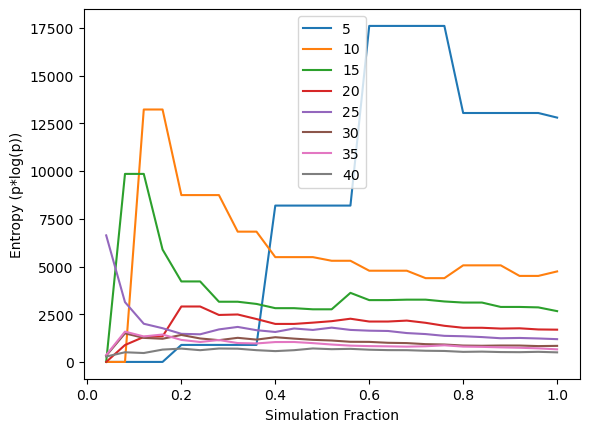

In [20]:
def plot_clusters(num_clusters, data):
    plt.clf()
    labels = KMeans(n_clusters=num_clusters).fit_predict(data)
    _ = plt.scatter(np.arange(coords.shape[0]), labels)
    plt.xlabel('Frame')
    plt.ylabel('Cluster ID')
    plt.yticks(np.arange(num_clusters))
    plt.show()

In [21]:
for i in range(clusters.shape[0]):
    print(clusters[i], sil_scores[i])

2 0.13411123
3 0.12677808
4 0.1276184
5 0.13269803
6 0.15160356
7 0.1646999
8 0.16667642
9 0.1716947
10 0.17003877
11 0.17162149
12 0.17639695
13 0.1738251
14 0.17926149
15 0.1797986
16 0.18157512
17 0.18090206
18 0.183963
19 0.18392834
20 0.18443176
21 0.18238465
22 0.18437937
23 0.18399397
24 0.18631497
25 0.18447176
26 0.18342933
27 0.18266128
28 0.18264036
29 0.18305452
30 0.18717253
31 0.18465464
32 0.18193059
33 0.18544649
34 0.18283652
35 0.1844638
36 0.18373705
37 0.18574424
38 0.18093614
39 0.18348205
40 0.18445098
41 0.18406078
42 0.18475941
43 0.1848518
44 0.18346265
45 0.18633504
46 0.18232344
47 0.18292287
48 0.18351933
49 0.1846604
50 0.18442827
51 0.1806119
52 0.18392469
53 0.18126374
54 0.18430232
55 0.18064317
56 0.18227038
57 0.18384825
58 0.18275338
59 0.1830764
60 0.18389104
61 0.1816627
62 0.17927676
63 0.18207349
64 0.18356971
65 0.18071936
66 0.17899005
67 0.18099588
68 0.18316722
69 0.18025279
70 0.18276009
71 0.17904912
72 0.18210152
73 0.18182378
74 0.18074185

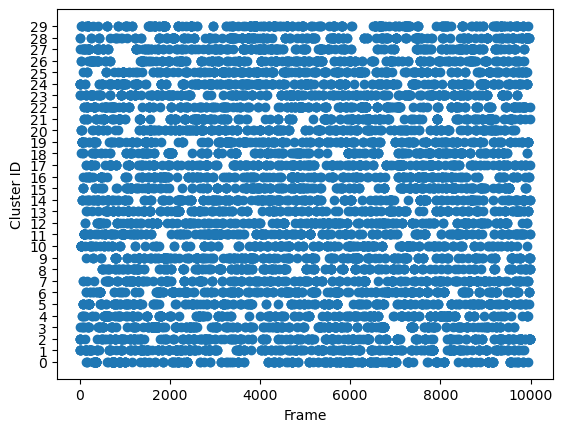

In [22]:
plot_clusters(30, coords)

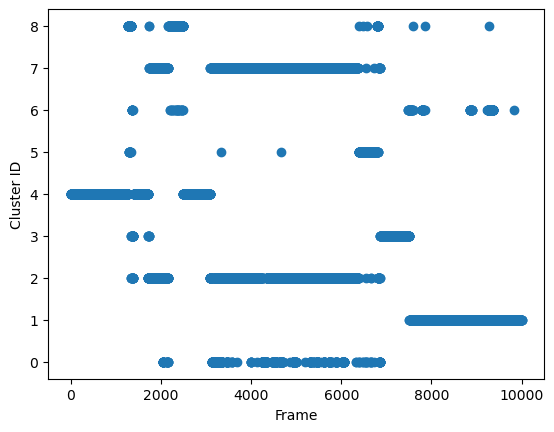

In [24]:
plot_clusters(9, coords)

### Plot the Loss

In [ ]:
self.plot_losses()

### Plot the Latents

In [ ]:
rng_seed = 8925
rng = jax.random.PRNGKey(rng_seed)
rng, key = jax.random.split(rng)
decoded, latent = self.state.apply_fn({'params':self.state.params}, self.test_data, rng)

In [ ]:
for i in range(self.n_latents):
    plt.clf()
    _ = plt.hist(latent[:, i], bins=50)
    plt.title(f'Latent {i}')
    plt.show()

In [ ]:
fig, axs = plt.subplots(self.n_latents, self.n_latents,
                        figsize=(15, 10), sharex='col')
for i in range(self.n_latents):
    for j in range(self.n_latents):
        #axs[i,j].scatter(latent[:,j], latent[:,i])
        if i > j:
            axs[i,j].scatter(latent[:,j], latent[:,i])
        elif i == j:
            axs[i,j].hist(latent[:, i], bins=25)


### Gaussian Mixture Model

In [ ]:
from sklearn.mixture import GaussianMixture

In [ ]:
ics = []
X = np.array(latent)
for i in range(1, 31):
    MM = GaussianMixture(n_components=i).fit(latent)
    ics.append((i, MM.aic(X), MM.bic(X)))
ics = np.array(ics)
plt.clf()
_ = plt.plot(ics[:, 0], ics[:, 1])
_ = plt.plot(ics[:, 0], ics[:, 2])
plt.legend(('Akaike Info Criterion', 'Bayes Info Criterion'))
plt.xlabel('Num Components')
plt.show()

In [ ]:
MM = GaussianMixture(n_components=5).fit(X) #chosen based on above graph
samples = MM.sample(latent.shape[0])[0]

In [ ]:
for i in range(samples.shape[-1]):
    plt.clf()
    _ = plt.hist(latent[:,i], bins=25, histtype='step', color='g')
    _ = plt.hist(samples[:,i], bins=25, histtype='step', color='b')
    plt.legend(('Reconstructed from Input', 'Sampled from Mixture Model'))
    plt.title(f'Latent {i+1}')
    plt.show()

### Plot Energies

In [ ]:
test_ener = self.math.ener_fun(self.test_data)
decoded_ener = self.math.ener_fun(decoded)
gmm_atomistic = self.state.apply_fn({'params': self.state.params}, samples, rng, method=self.model.decode)
gmm_ener = self.math.ener_fun(gmm_atomistic)

In [ ]:
plt.clf()
_ = plt.hist(test_ener, bins=25)
plt.show()
thresh = 7e6
_ = plt.hist(decoded_ener[decoded_ener < thresh], bins=25, histtype='step')
_ = plt.hist(gmm_ener[gmm_ener < thresh], bins=25, histtype='step')

### Distance Matrics

#### Test Data

In [ ]:
plt.matshow(self.math.rmsd_distance_matrix(self.test_data, self.test_data))

#### Decoded Test Data

In [ ]:
plt.matshow(self.math.rmsd_distance_matrix(decoded, decoded))

#### Decoded Gaussian Mixture Model

In [ ]:
plt.matshow(self.math.rmsd_distance_matrix(gmm_atomistic, gmm_atomistic))

## BAT JAX Development Block

In [18]:
from MDAnalysis.analysis.bat import BAT 
import logging
import jax
import jax.numpy as jnp
import copy
import timeit 

import MDAnalysis as mda
from MDAnalysis.analysis.base import AnalysisBase

from MDAnalysis.lib.distances import calc_bonds, calc_angles, calc_dihedrals
from MDAnalysis.lib.mdamath import make_whole

from MDAnalysis.due import due, Doi

logger = logging.getLogger(__name__)

In [19]:
def _sort_atoms_by_mass(atoms, reverse=False):
    r"""Sorts a list of atoms by name and then by index

    The atom index is used as a tiebreaker so that the ordering is reproducible.

    Parameters
    ----------
    ag_o : list of Atoms
        List to sort
    reverse : bool
        Atoms will be in descending order

    Returns
    -------
    ag_n : list of Atoms
        Sorted list
    """
    return sorted(atoms, key=lambda a: (a.mass, a.index), reverse=reverse)


def _find_torsions(root, atoms):
    """Constructs a list of torsion angles

    Parameters
    ----------
    root : AtomGroup
        First three atoms in the coordinate system
    atoms : AtomGroup
        Atoms that are allowed to be part of the torsion angle

    Returns
    -------
    torsions : list of AtomGroup
        list of AtomGroup objects that define torsion angles
    """
    start = timeit.default_timer()
    print("Starting torsions calculation.")
    torsions = []
    selected_atoms = list(root)
    while len(selected_atoms) < len(atoms):
        torsionAdded = False
        for a1 in selected_atoms:
            # Find a0, which is a new atom connected to the selected atom
            a0_list = _sort_atoms_by_mass(a for a in a1.bonded_atoms \
                if (a in atoms) and (a not in selected_atoms))
            for a0 in a0_list:
                # Find a2, which is connected to a1, is not a terminal atom,
                # and has been selected
                a2_list = _sort_atoms_by_mass(a for a in a1.bonded_atoms \
                    if (a!=a0) and len(a.bonded_atoms)>1 and \
                        (a in atoms) and (a in selected_atoms))
                for a2 in a2_list:
                    # Find a3, which is
                    # connected to a2, has been selected, and is not a1
                    a3_list = _sort_atoms_by_mass(a for a in a2.bonded_atoms \
                        if (a!=a1) and \
                            (a in atoms) and (a in selected_atoms))
                    for a3 in a3_list:
                        # Add the torsion to the list of torsions
                        torsions.append(mda.AtomGroup([a0, a1, a2, a3]))
                        # Add the new atom to selected_atoms
                        # which extends the loop
                        selected_atoms.append(a0)
                        torsionAdded = True
                        break  # out of the a3 loop
                    break  # out of the a2 loop
        if torsionAdded is False:
            print('Selected atoms:')
            print([a.index + 1 for a in selected_atoms])
            print('Torsions found:')
            print([list(t.indices + 1) for t in torsions])
            raise ValueError('Additional torsions not found.')
    stop = timeit.default_timer()
    print(f"Torsions calculation took {stop-start}s.")
    return torsions

class BAT_jax(BAT):

    @due.dcite(Doi("10.1002/jcc.26036"),
               description="Bond-Angle-Torsions Coordinate Transformation",
               path="MDAnalysis.analysis.bat.BAT")
    def __init__(self, ag, initial_atom=None, filename=None, **kwargs):
        r"""Parameters
        ----------
        ag : AtomGroup or Universe
            Group of atoms for which the BAT coordinates are calculated.
            `ag` must have a bonds attribute.
            If unavailable, bonds may be guessed using
            :meth:`AtomGroup.guess_bonds <MDAnalysis.core.groups.AtomGroup.guess_bonds>`.
            `ag` must only include one molecule.
            If a trajectory is associated with the atoms, then the computation
            iterates over the trajectory.
        initial_atom : :class:`Atom <MDAnalysis.core.groups.Atom>`
            The atom whose Cartesian coordinates define the translation
            of the molecule. If not specified, the heaviest terminal atom
            will be selected.
        filename : str
            Name of a numpy binary file containing a saved bat array.
            If filename is not ``None``, the data will be loaded from this file
            instead of being recalculated using the run() method.

        Raises
        ------
        AttributeError
            If `ag` does not contain a bonds attribute
        ValueError
            If `ag` contains more than one molecule

        """
        super(BAT, self).__init__(ag.universe.trajectory, **kwargs)
        self._ag = ag

        # Check that the ag contains bonds
        if not hasattr(self._ag, 'bonds'):
            raise AttributeError('AtomGroup has no attribute bonds')
        if len(self._ag.fragments) > 1:
            raise ValueError('AtomGroup has more than one molecule')

        # Determine the root
        # The initial atom must be a terminal atom
        terminal_atoms = _sort_atoms_by_mass(\
            [a for a in self._ag.atoms if len(a.bonds)==1], reverse=True)
        if (initial_atom is None):
            # Select the heaviest root atoms from the heaviest terminal atom
            initial_atom = terminal_atoms[0]
        elif (not initial_atom in terminal_atoms):
            raise ValueError('Initial atom is not a terminal atom')
        # The next atom in the root is bonded to the initial atom
        # Since the initial atom is a terminal atom, there is only
        # one bonded atom
        second_atom = initial_atom.bonded_atoms[0]
        # The last atom in the root is the heaviest atom
        # bonded to the second atom
        # If there are more than three atoms,
        # then the last atom cannot be a terminal atom.
        if self._ag.n_atoms != 3:
            third_atom = _sort_atoms_by_mass(\
                [a for a in second_atom.bonded_atoms \
                if (a in self._ag) and (a!=initial_atom) \
                and (a not in terminal_atoms)], \
                reverse=True)[0]
        else:
            third_atom = _sort_atoms_by_mass(\
                [a for a in second_atom.bonded_atoms \
                if (a in self._ag) and (a!=initial_atom)], \
                reverse=True)[0]
        self._root = mda.AtomGroup([initial_atom, second_atom, third_atom])

        # Construct a list of torsion angles
        self._torsions = _find_torsions(self._root, self._ag)

        # Get indices of the root and torsion atoms
        # in a Cartesian positions array that matches the AtomGroup
        self._root_XYZ_inds = [(self._ag.indices==a.index).nonzero()[0][0] \
            for a in self._root]
        self._torsion_XYZ_inds = [[(self._ag.indices==a.index).nonzero()[0][0] \
            for a in t] for t in self._torsions]

        # The primary torsion is the first torsion on the list
        # with the same central atoms
        prior_atoms = [sorted([a1, a2]) for (a0, a1, a2, a3) in self._torsions]
        self._primary_torsion_indices = [prior_atoms.index(prior_atoms[n]) \
            for n in range(len(prior_atoms))]
        self._unique_primary_torsion_indices = \
            list(set(self._primary_torsion_indices))

        self._ag1 = mda.AtomGroup([ag[0] for ag in self._torsions])
        self._ag2 = mda.AtomGroup([ag[1] for ag in self._torsions])
        self._ag3 = mda.AtomGroup([ag[2] for ag in self._torsions])
        self._ag4 = mda.AtomGroup([ag[3] for ag in self._torsions])

        if filename is not None:
            self.load(filename)

        self.VCartesian = jax.vmap(self.Cartesian)
    
    def _prepare(self):
        jax.dtypes.canonicalize_dtype(jnp.float64)
        self.results.bat = jnp.zeros(
                (self.n_frames, 3*self._ag.n_atoms), dtype=jnp.float64)

    def _single_frame(self):
    # Calculate coordinates based on the root atoms
    # The rotation axis is a normalized vector pointing from atom 0 to 1
    # It is described in two degrees of freedom
    # by the polar angle and azimuth
        if self._root.dimensions is None:
            (p0, p1, p2) = self._root.positions
        else:
            (p0, p1, p2) = make_whole(self._root, inplace=False)
        v01 = p1 - p0
        v21 = p1 - p2
        # Internal coordinates
        r01 = jnp.sqrt(jnp.dot(v01, v01))  
        # Distance between first two root atoms
        r12 = jnp.sqrt(jnp.dot(v21, v21))  
        # Distance between second two root atoms
        # Angle between root atoms
        a012 = jnp.arccos(jnp.maximum(-1., jnp.minimum(1., jnp.dot(v01, v21) /
                                (jnp.sqrt(jnp.dot(v01, v01)) * jnp.sqrt(jnp.dot(v21, v21))))))

        # External coordinates
        e = v01 / r01
        phi = jnp.arctan2(e[1], e[0])  # Polar angle
        theta = jnp.arccos(e[2])  # Azimuthal angle
        # Rotation to the z axis
        cp = jnp.cos(phi)
        sp = jnp.sin(phi)
        ct = jnp.cos(theta)
        st = jnp.sin(theta)
        Rz = jnp.array([[cp * ct, ct * sp, -st], [-sp, cp, 0],
                        [cp * st, sp * st, ct]])
        pos2 = jnp.dot(Rz, p2 - p1)
        # Angle about the rotation axis
        omega = jnp.arctan2(pos2[1], pos2[0])
        root_based = jnp.concatenate((p0, jnp.array([phi, theta, omega, r01, r12, a012])))

        # Calculate internal coordinates from the torsion list
        bonds = calc_bonds(self._ag1.positions,self._ag2.positions,box=self._ag1.dimensions)
        angles = calc_angles(self._ag1.positions,self._ag2.positions,self._ag3.positions,box=self._ag1.dimensions)
        torsions = calc_dihedrals(self._ag1.positions,self._ag2.positions,self._ag3.positions,self._ag4.positions,box=self._ag1.dimensions)
        
        # When appropriate, calculate improper torsions
        shift = torsions[self._primary_torsion_indices]
        shift[self._unique_primary_torsion_indices] = 0.
        torsions -= shift
        
        # Wrap torsions to between -jnp.pi and jnp.pi
        torsions = ((torsions + jnp.pi) % (2 * jnp.pi)) - jnp.pi

        self.results.bat = self.results.bat.at[self._frame_index, :].set(jnp.concatenate(
                (root_based, bonds, angles, torsions)))

    def save(self, filename):
        """Saves the bat trajectory in a file in numpy binary format

        See Also
        --------
        load: Loads the bat trajectory from a file in numpy binary format
        """
        jnp.save(filename, self.results.bat)

    def Cartesian(self, bat_frame):
        """Conversion of a single frame from BAT to Cartesian coordinates

        One application of this function is to determine the new
        Cartesian coordinates after modifying a specific torsion angle.

        Parameters
        ----------
        bat_frame : numpy.ndarray
            an array with dimensions (3N,) with external then internal
            degrees of freedom based on the root atoms, followed by the bond,
            angle, and (proper and improper) torsion coordinates.

        Returns
        -------
        XYZ : numpy.ndarray
            an array with dimensions (N,3) with Cartesian coordinates. The first
            dimension has the same ordering as the AtomGroup used to initialize
            the class. The molecule will be whole opposed to wrapped around a
            periodic boundary.
        """
        start = timeit.default_timer()
        print("Starting Cartesian calculation.")
   
        origin = bat_frame[:3]
        (phi, theta, omega) = bat_frame[3:6]
        (r01, r12, a012) = bat_frame[6:9]
        n_torsions = (self._ag.n_atoms - 3)
        bonds = bat_frame[9:n_torsions + 9]
        angles = bat_frame[n_torsions + 9:2 * n_torsions + 9]
        torsions = copy.deepcopy(bat_frame[2 * n_torsions + 9:])
        # When appropriate, convert improper to proper torsions
        shift = torsions[jnp.array(self._primary_torsion_indices)]
        shift = shift.at[jnp.array(self._unique_primary_torsion_indices)].set(0.)
        torsions += shift
        # Wrap torsions to between -np.pi and np.pi
        torsions = ((torsions + jnp.pi) % (2 * jnp.pi)) - jnp.pi

        stop = timeit.default_timer()
        print(f"Midpoint 1 took {stop-start}s.")

        p0 = jnp.array([0., 0., 0.])
        p1 = jnp.array([0., 0., r01])
        p2 = jnp.array([r12 * jnp.sin(a012), 0., r01 - r12 * jnp.cos(a012)])

        co = jnp.cos(omega)
        so = jnp.sin(omega)
        Romega = jnp.array([[co, -so, 0], [so, co, 0], [0, 0, 1]])
        p2 = jnp.dot(Romega, p2)

        cp = jnp.cos(phi)
        sp = jnp.sin(phi)
        ct = jnp.cos(theta)
        st = jnp.sin(theta)
        Re = jnp.array([[cp * ct, -sp, cp * st], [ct * sp, cp, sp * st], [-st, 0, ct]])
        p1 = jnp.dot(Re, p1)
        p2 = jnp.dot(Re, p2)

        p0 += origin
        p1 += origin
        p2 += origin

        XYZ = jnp.zeros((self._ag.n_atoms, 3))

        XYZ = XYZ.at[self._root_XYZ_inds[0]].set(p0)
        XYZ = XYZ.at[self._root_XYZ_inds[1]].set(p1)
        XYZ = XYZ.at[self._root_XYZ_inds[2]].set(p2)

        stop = timeit.default_timer()
        print(f"Midpoint 2 took {stop-start}s.")

        for ((a0, a1, a2, a3), r01, angle, torsion) in zip(self._torsion_XYZ_inds, bonds, angles, torsions):
            p1 = XYZ[a1]
            p3 = XYZ[a3]
            p2 = XYZ[a2]

            sn_ang = jnp.sin(angle)
            cs_ang = jnp.cos(angle)
            sn_tor = jnp.sin(torsion)
            cs_tor = jnp.cos(torsion)

            v21 = p1 - p2
            v21 /= jnp.sqrt(jnp.einsum('i,i->', v21, v21))
            v32 = p2 - p3
            v32 /= jnp.sqrt(jnp.einsum('i,i->', v32, v32))

            vp = jnp.cross(v32, v21)
            cs = jnp.einsum('i,i->', v21, v32)

            sn = jnp.maximum(jnp.sqrt(1.0 - cs * cs), 0.0000000001)
            vp = vp / sn
            vu = jnp.cross(vp, v21)

            XYZ = XYZ.at[a0].set(p1 + r01*(vu*sn_ang*cs_tor + vp*sn_ang*sn_tor - v21*cs_ang))
        
        stop = timeit.default_timer()
        print(f"Cartesian calculation took {stop-start}s.")
        
        return XYZ   

In [20]:
# Load a trajectory or create an AtomGroup
# Replace 'your_trajectory.xyz' with the actual trajectory file
u = mda.Universe('Simulation/ala_deca_peptide.pdb', 'Simulation/decaalanine_1us_split3.dcd')
ag = u.select_atoms("protein")
ag.guess_bonds()

/home/exouser/miniconda3/envs/jax_12/lib/python3.12/site-packages/MDAnalysis/coordinates/DCD.py:165: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


In [21]:
# Create a BAT_jax object
bat_analysis = BAT_jax(ag)

Starting torsions calculation.
Torsions calculation took 0.2207582629926037s.


In [22]:
# Run the analysis
start = timeit.default_timer()
bat_analysis.run()
stop = timeit.default_timer()
print('Time:', stop-start)

/tmp/ipykernel_38936/1969013290.py:179: UserWarning: Explicitly requested dtype <class 'jax.numpy.float64'> requested in zeros is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  self.results.bat = jnp.zeros(


Time: 84.8915420990088


In [23]:
# # Save the results to a file
# bat_analysis.save("bat_result.npy")

In [27]:
# Access the results if needed
bat_trajectory = bat_analysis.results.bat[:2000, :]
print(bat_trajectory.shape, type(bat_trajectory))

(2000, 306) <class 'jaxlib.xla_extension.ArrayImpl'>


In [28]:
start = timeit.default_timer()
cartesian_coordinates = bat_analysis.VCartesian(bat_trajectory).reshape(bat_trajectory.shape[0], -1)
stop = timeit.default_timer()
print('Time:', stop-start)

Starting Cartesian calculation.
Midpoint 1 took 0.012726385990390554s.
Midpoint 2 took 0.04628193998360075s.
Cartesian calculation took 1.7108264669950586s.
Time: 1.726033382001333


In [30]:
print(cartesian_coordinates.shape)
print(type(cartesian_coordinates))

(2000, 306)
<class 'jaxlib.xla_extension.ArrayImpl'>
